# MSCS 634 – Lab 2
## K-Nearest Neighbors (KNN) and Radius Neighbors (RNN)
**Name:** Anusha Sharma

### Objective
The objective of the Lab is to analyze and compare the performance of K-Nearest Neighbors and Radius Neighbors classifiers on the basis of Wine Dataset from sklearn. Various k and radius values will be used in order to see their effect on classification accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
wine = load_wine()

X = wine.data
y = wine.target

print("Dataset loaded successfully.")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", wine.target_names)

Dataset loaded successfully.
Number of samples: 178
Number of features: 13
Classes: ['class_0' 'class_1' 'class_2']


In [3]:
df = pd.DataFrame(X, columns=wine.feature_names)
df["target"] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print("Feature Names:")
print(wine.feature_names)

print("\nDataset Shape:")
print(df.shape)

print("\nClass Distribution:")
print(df["target"].value_counts().sort_index())

Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Dataset Shape:
(178, 14)

Class Distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


### Dataset Exploration

The Wine Dataset contains 178 samples with 13 numerical features representing
different chemical properties of wine. The dataset contains three target
classes. Class 0 contains 59 samples, Class 1 contains 71 samples, and Class 2
contains 48 samples. The classes are reasonably distributed, although they are
not exactly equal in size.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 142
Testing samples: 36


In [6]:
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    knn_accuracies.append(accuracy)

    print(f"k = {k}, Accuracy = {accuracy:.4f}")

k = 1, Accuracy = 0.7778
k = 5, Accuracy = 0.8056
k = 11, Accuracy = 0.8056
k = 15, Accuracy = 0.8056
k = 21, Accuracy = 0.8056


In [7]:
knn_results = pd.DataFrame({
    "K Value": k_values,
    "Accuracy": knn_accuracies
})

knn_results

,K Value,Accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


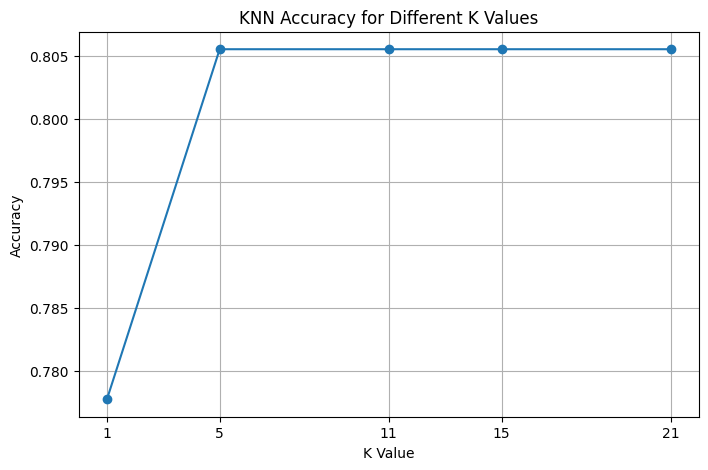

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, knn_accuracies, marker="o")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [9]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

for radius in radius_values:
    rnn = RadiusNeighborsClassifier(
        radius=radius,
        outlier_label="most_frequent"
    )

    rnn.fit(X_train, y_train)

    y_pred = rnn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    rnn_accuracies.append(accuracy)

    print(f"Radius = {radius}, Accuracy = {accuracy:.4f}")

Radius = 350, Accuracy = 0.7222
Radius = 400, Accuracy = 0.6944
Radius = 450, Accuracy = 0.6944
Radius = 500, Accuracy = 0.6944
Radius = 550, Accuracy = 0.6667
Radius = 600, Accuracy = 0.6667


In [10]:
rnn_results = pd.DataFrame({
    "Radius": radius_values,
    "Accuracy": rnn_accuracies
})

rnn_results

,Radius,Accuracy
0,350,0.722222
1,400,0.694444
2,450,0.694444
3,500,0.694444
4,550,0.666667
5,600,0.666667


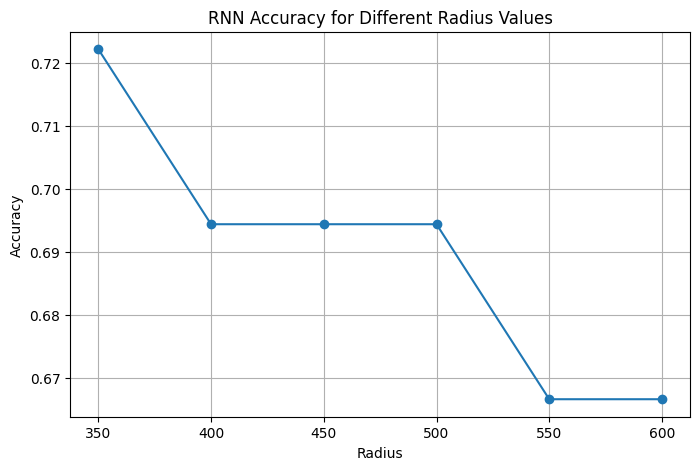

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(radius_values, rnn_accuracies, marker="o")

plt.xlabel("Radius")
plt.ylabel("Accuracy")
plt.title("RNN Accuracy for Different Radius Values")
plt.xticks(radius_values)
plt.grid(True)

plt.show()

In [13]:
best_k_index = np.argmax(knn_accuracies)
best_radius_index = np.argmax(rnn_accuracies)

print("Best K:", k_values[best_k_index])
print("Best KNN Accuracy:", round(knn_accuracies[best_k_index], 4))

print("\nBest Radius:", radius_values[best_radius_index])
print("Best RNN Accuracy:", round(rnn_accuracies[best_radius_index], 4))

Best K: 5
Best KNN Accuracy: 0.8056

Best Radius: 350
Best RNN Accuracy: 0.7222


**KNN vs RNN comparison**

It is possible to say that the quality of both models depends on the parameters used. In the case of KNN, the variation of k influences the result because the parameter k defines the amount of training samples' neighbors used in the classification process.

When the value of k is low, it makes the classifier more susceptible to each neighbor. Otherwise, when the value of k is high, it takes into account more training samples. Some k-values gave better results than other, and it shows the importance of the parameter's choice.

In RNN model, the radius determines the neighbors. With the increase of the radius, the amount of observations used for the classification process increases. It is possible to say that the variation of the radius influences the accuracy of the model.

Generally speaking, the advantage of KNN model is the simplicity of its use because each observation in the test data is classified by the same number of neighbors. RNN model may be useful when there is a change in the density of the observations since it uses the distance to find the neighbors. But, the parameter of the radius should be chosen properly.